# Bayesian Inference for Mass-Action Kinetics Model

This notebook performs MCMC inference on the Mass-Action (MA), Michaelis-Menten (MM) or Hill model using PyMC with JAX backend.

Based on inference_pymc.py by Nathaniel Linden (UCSD MAE) - 2024

Edited by Annette Thompson (CU Boulder) - 2026

## Import Libraries

In [45]:
import os, jax, json
import jax.numpy as jnp
import numpy as np
import pandas as pd
import diffrax as dfrx
import equinox as eqx
import pymc as pm
import arviz as az

from jax import random
from pytensor.link.jax.dispatch import jax_funcify

from utils import *
from MA_diffrax import *
from MM_diffrax import *
from Hill_diffrax import *

os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"

print(f"JAX version: {jax.__version__}")
print(f"PyMC version: {pm.__version__}")
print(f"Number of JAX devices: {jax.device_count()}")

JAX version: 0.7.0
PyMC version: 5.27.1
Number of JAX devices: 4


## Set Parameters

These used to be the command line arguments.

Run only one of the cells below (represent different models from Figure 3).

In [46]:
# MA model

model_name = "MA"
free_params = "k_f,k_r,k_cat"
data_file = "./Data/Duggleby_Clarke_1991_Fig2.csv"
reaction_setup_file = "./MA_pyruvate_kinase.json"
savedir = "./MA_Results"

# Prior parameters
prior_family = "[['Gamma()',['alpha', 'beta']]]"
prior_lower_bound_multiplier = 0.1
prior_upper_bound_multiplier = 2.0

# MCMC parameters
nwarmup = 300
nsamples = 200
nchains = 4
seed = 0

# ODE solver parameters
rtol = 1e-9
atol = 1e-9
pcoeff = 0.3
icoeff = 0.4
dcoeff = 0.0

print("MA Model:")
print(f"Free Parameters: {free_params}")
print(f"MCMC Setup: {nchains} chains, {nwarmup} warmup, {nsamples} samples")

MA Model:
Free Parameters: k_f,k_r,k_cat
MCMC Setup: 4 chains, 300 warmup, 200 samples


In [47]:
# MM model

model_name = "MM"
free_params = "V_max,K_m"
data_file = "./Data/Duggleby_Clarke_1991_Fig2.csv"
reaction_setup_file = "./MM_pyruvate_kinase.json"
savedir = "./MM_Results"

# Prior parameters
prior_family = "[['Gamma()',['alpha', 'beta']]]"
prior_lower_bound_multiplier = 0.1
prior_upper_bound_multiplier = 2.0

# MCMC parameters
nwarmup = 300
nsamples = 200
nchains = 4
seed = 0

# ODE solver parameters
rtol = 1e-9
atol = 1e-9
pcoeff = 0.3
icoeff = 0.4
dcoeff = 0.0

print("MM Model:")
print(f"Free Parameters: {free_params}")
print(f"MCMC Setup: {nchains} chains, {nwarmup} warmup, {nsamples} samples")

MM Model:
Free Parameters: V_max,K_m
MCMC Setup: 4 chains, 300 warmup, 200 samples


In [48]:
# Hill model

model_name = "Hill"
free_params = "V_max,K_m,n"
data_file = "./Data/Duggleby_Clarke_1991_Fig2.csv"
reaction_setup_file = "./Hill_pyruvate_kinase.json"
savedir = "./Hill_Results"

# Prior parameters
prior_family = "[['Gamma()',['alpha', 'beta']],['Gamma()',['alpha', 'beta']],['TruncatedNormal(lower=1)',['mu', 'sigma']]]"
prior_lower_bound_multiplier = 0.1
prior_upper_bound_multiplier = 2.0

# MCMC parameters
nwarmup = 300
nsamples = 200
nchains = 4
seed = 0

# ODE solver parameters
rtol = 1e-10
atol = 1e-10
pcoeff = 0.3
icoeff = 0.4
dcoeff = 0.0

print("Hill Model:")
print(f"Free Parameters: {free_params}")
print(f"MCMC Setup: {nchains} chains, {nwarmup} warmup, {nsamples} samples")

Hill Model:
Free Parameters: V_max,K_m,n
MCMC Setup: 4 chains, 300 warmup, 200 samples


## Create Save Directory

In [49]:
# Create save directory if it doesn't exist
if not os.path.isdir(savedir):
    os.makedirs(savedir)
    print(f"Created directory: {savedir}")
else:
    print(f"Save directory exists: {savedir}")

Save directory exists: ./Hill_Results


## Load Model Reactions 

In [50]:
# Load JSON file with parameter, product/substrate states, and initial concentrations
with open(reaction_setup_file, 'r') as file:
    reaction_setup = json.load(file)

# Unpack loaded reaction setup dictionary
state_names = list(reaction_setup["init_conds"].keys())
sub_prod_states = reaction_setup["sub_prod_states"]
prod_states = reaction_setup["prod_states"]
y0 = list(reaction_setup["init_conds"].values())

# Get the indices of the states needed for likelihood calculation
sub_prod_idxs = [state_names.index(item) for item in sub_prod_states]
prod_idxs = [state_names.index(item) for item in prod_states]

# Process the parameters 
free_params_list = free_params.split(',')

print(f"State names: {state_names}")
print(f"Initial conditions: {y0}")
print(f"Free parameters: {free_params_list}")
print(f"Product states: {prod_states}")
print(f"All substrate or product states: {sub_prod_states}")

State names: ['S', 'P']
Initial conditions: [0.195, 0.0]
Free parameters: ['V_max', 'K_m', 'n']
Product states: ['P']
All substrate or product states: ['S', 'P']


## Load Data

In [51]:
# Load the data
loaded_data = pd.read_csv(data_file)
times = loaded_data['time'].to_numpy()
data = loaded_data['[P]/[S_tot]'].to_numpy()

# Assume data std is 5% of the mean
data_std = 0.05 * np.mean(data)

print(f"Data loaded from: {data_file}")
print(f"Number of time points: {len(times)}")
print(f"Time range: {times[0]:.1f} to {times[-1]:.1f} minutes")
print(f"Data mean: {np.mean(data):.2f}, std: {data_std:.2f}")

# Display data points
display(loaded_data)

Data loaded from: ./Data/Duggleby_Clarke_1991_Fig2.csv
Number of time points: 11
Time range: 0.0 to 23.3 minutes
Data mean: 0.34, std: 0.02


,time,[P]/[S_tot]
0,0.0,0.00
1,2.3,0.08
2,4.7,0.16
3,7.0,0.23
4,9.4,0.29
5,11.7,0.36
6,14.0,0.42
7,16.4,0.48
8,18.7,0.52
9,21.0,0.58


## Define Simulator Function

In [52]:
# ODE solver setup
solver = dfrx.Kvaerno5()
stepsize_controller = dfrx.PIDController(rtol, atol, pcoeff=pcoeff, icoeff=icoeff, dcoeff=dcoeff)
saveat = dfrx.SaveAt(ts=times)
t0 = 0.0
t1 = times[-1]
dt0 = 1e-12
y0_jax = jnp.array(y0)

# Create the ODE term
model_func = eval(model_name+'()')
rhs = dfrx.ODETerm(model_func)

def simulator(params):
    """Solve ODE and compute product/(substrate + product) ratio"""

    sol = dfrx.diffeqsolve(
        rhs, solver, t0=t0, t1=t1, dt0=dt0, 
        y0=y0_jax, args=params, saveat=saveat,
        stepsize_controller=stepsize_controller,
        max_steps=10000000, throw=True
    )
    sol = jnp.squeeze(sol.ys)

    sub_prod = sol[:, jnp.array(sub_prod_idxs)].sum(axis=1)
    prod = sol[:, jnp.array(prod_idxs)].sum(axis=1)
    result = prod / sub_prod

    return result.reshape(1, len(result))

print("Simulator function defined.")

Simulator function defined.


## Create PyTensor Ops for PyMC Integration

In [53]:
# Construct PyTensor Op for simulator
def sol_op_jax(*params):
    return simulator(params)

# JIT compile the simulator function (traces JAX and np arrays, keeps all other params static)
sol_op_jax_jitted = eqx.filter_jit(sol_op_jax)

# Define the VJP (vector-Jacobian product) function for the simulator
def vjp_sol_op_jax(gz, *params):
    _, vjp_fn = jax.vjp(sol_op_jax, *params)
    return vjp_fn(gz)

# JIT compile the VJP function
vjp_sol_op_jax_jitted = eqx.filter_jit(vjp_sol_op_jax)

# Create PyTensor Ops for the simulator and its VJP (see utils.py for SolOp and VJPSolOp definitions)
vjp_sol_op = VJPSolOp(vjp_sol_op_jax_jitted)
sol_op = SolOp(sol_op_jax_jitted, vjp_sol_op)

# Register the ops with PyTensor
@jax_funcify.register(SolOp)
def sol_op_jax_funcify(op, **kwargs):
    return sol_op_jax

@jax_funcify.register(VJPSolOp)
def vjp_sol_op_jax_funcify(op, **kwargs):
    return vjp_sol_op_jax

print("PyTensor operations registered.")

PyTensor operations registered.


## Build PyMC Model

In [54]:
# Set up priors for free parameters based on nominal values and specified multipliers 
# (see utils.py for set_prior_params function)
prior_dict = set_prior_params(
    list(reaction_setup["nominal_params"].keys()), 
    free_params_list, 
    reaction_setup["nominal_params"], 
    upper_mult=prior_upper_bound_multiplier, 
    lower_mult=prior_lower_bound_multiplier, 
    prior_family=prior_family
)

print("\nPrior parameters:")
for param, prior in prior_dict.items():
    print(f"  {param}: {prior}")

# Build PyMC model (see utils.py for build_pymc_model function)
pm_model = build_pymc_model(
    list(reaction_setup["nominal_params"].keys()),
    prior_dict, 
    data.reshape(1, len(data)), 
    sol_op, 
    data_sigma=data_std
)

print("\nPyMC model built successfully.")


Prior parameters:
  V_max: pm.Gamma("V_max",alpha=2.9041058827111876, beta=3150.0006597492666, )
  K_m: pm.Gamma("K_m",alpha=3.140236759777055, beta=132.012754038353, )
  n: pm.TruncatedNormal("n",mu=1.3914535540081447, sigma=0.3550030171606931, lower=1, )

PyMC model built successfully.


## Sample from Prior

In [55]:
with pm_model:
    prior_pred = pm.sample_prior_predictive(samples=10000, random_seed=seed)

# Save prior samples
prior_file = os.path.join(savedir, f'{model_name}_prior_samples_pm.nc')
if os.path.exists(prior_file):
    os.remove(prior_file)
    print(f"Removed existing file: {prior_file}")
prior_pred.to_netcdf(prior_file)
print(f"Prior samples saved to: {prior_file}")

Sampling: [K_m, V_max, llike, n]


Removed existing file: ./Hill_Results/Hill_prior_samples_pm.nc
Prior samples saved to: ./Hill_Results/Hill_prior_samples_pm.nc


## Run MCMC Sampling

In [56]:
with pm_model:
    posterior = pm.sample(
        nsamples, 
        tune=nwarmup, 
        chains=nchains, 
        cores=None, # Use all available CPU cores (up to 4)
        nuts_sampler='nutpie', # Changed from 'pymc' to 'nutpie' for faster performance (both NUTS implementations)
        random_seed=seed
    )
    pm.compute_log_likelihood(posterior, model=pm_model, progressbar=False)

print("MCMC sampling complete.")

/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run SolOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run VJPSolOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run SolOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,500,0,0.29,31
,500,1,0.23,11
,500,0,0.27,31
,500,0,0.28,63


MCMC sampling complete.


## Posterior Predictive Sampling

In [57]:
post_pred = pm.sample_posterior_predictive(posterior, model=pm_model, progressbar=False)
print("Posterior predictive sampling complete.")

Sampling: [llike]


Posterior predictive sampling complete.


## Save Results

In [58]:
# Combine all results
posterior.extend(prior_pred)
posterior.extend(post_pred)

# Save as netcdf file
results_file = os.path.join(savedir, f'{model_name}_mcmc_samples_pm.nc')
if os.path.exists(results_file):
    os.remove(results_file)
    print(f"Removed existing file: {results_file}")
posterior.to_netcdf(results_file)

print(f"\nAll results saved to: {results_file}")

Removed existing file: ./Hill_Results/Hill_mcmc_samples_pm.nc

All results saved to: ./Hill_Results/Hill_mcmc_samples_pm.nc


## Display Summary Statistics and Plot Trace


=== MCMC Summary ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
V_max,0.0073,0.0006,0.0061,0.0085,0.0000,0.0000,206.3884,302.7935,1.0260
K_m,0.0161,0.0095,0.0023,0.0320,0.0008,0.0010,138.3056,155.3831,1.0361
n,1.5626,0.2600,1.0004,1.9311,0.0340,0.0184,65.7927,29.1392,1.0707


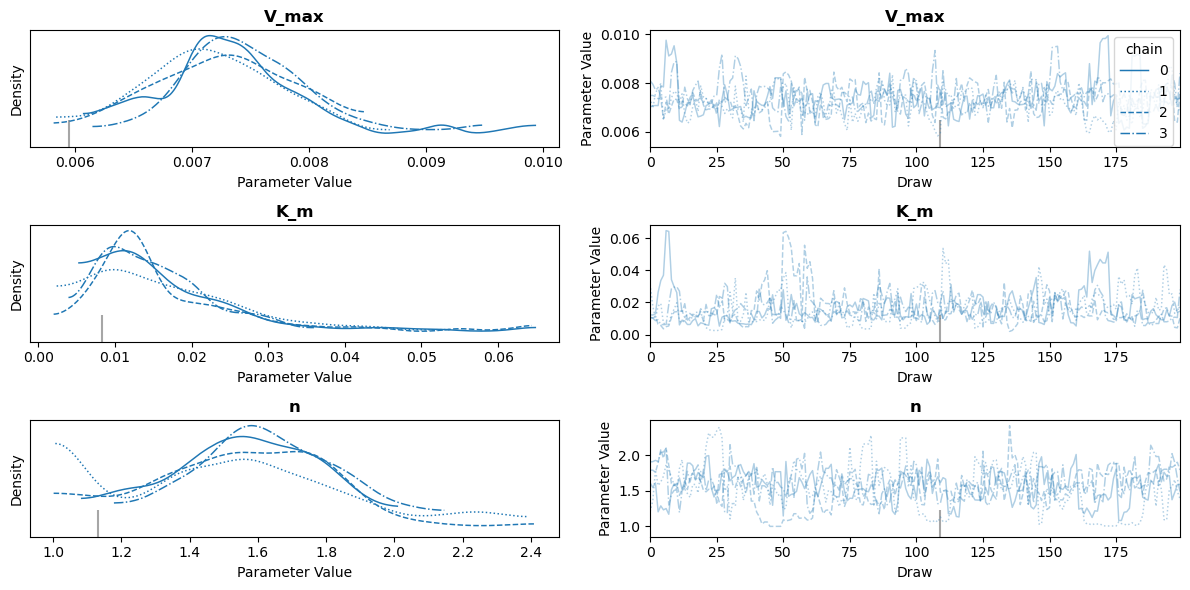

In [59]:
print("\n=== MCMC Summary ===")
summary = az.summary(posterior, var_names=free_params_list, round_to=4)
display(summary)

# Plot trace 
axes = az.plot_trace(posterior, var_names=free_params_list, legend=True)

for idx, ax_row in enumerate(axes):
    ax_row[0].set_title(ax_row[0].get_title(), fontweight='bold')
    ax_row[0].set_xlabel("Parameter Value")
    ax_row[0].set_ylabel("Density")
    ax_row[1].set_title(ax_row[1].get_title(), fontweight='bold')
    ax_row[1].set_xlabel("Draw")
    ax_row[1].set_ylabel("Parameter Value")
    
plt.style.use('default')
plt.tight_layout()